In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import get_linear_schedule_with_warmup
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import math
import time
import re
import warnings
warnings.simplefilter('ignore')

In [2]:
data = pd.read_csv('eng_french.csv')
data.rename(columns={'English words/sentences': 'English', 'French words/sentences': 'French'}, inplace=True)
data

,English,French
0,Hi.,Salut!
1,Run!,Cours !
2,Run!,Courez !
3,Who?,Qui ?
4,Wow!,Ça alors !
...,...,...
175616,"Top-down economics never works, said Obama. ""T...","« L'économie en partant du haut vers le bas, ç..."
175617,A carbon footprint is the amount of carbon dio...,Une empreinte carbone est la somme de pollutio...
175618,Death is something that we're often discourage...,La mort est une chose qu'on nous décourage sou...
175619,Since there are usually multiple websites on a...,Puisqu'il y a de multiples sites web sur chaqu...


In [3]:
batch_size = 256
num_epochs = 200

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"i'm", "i am", text) # replace "i'm" with "i am"
    text = re.sub(r"im", "i am", text)
    text = re.sub(r"ive", "i have", text)
    text = re.sub(r"he's", "he is", text)
    text = re.sub(r"she's", "she is", text)
    text = re.sub(r"that's", "that is", text)
    text = re.sub(r"what's", "what is", text)
    text = re.sub(r"where's", "where is", text)
    text = re.sub(r"how's", "how is", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"wont", "will not", text)
    text = re.sub(r"won t", "will not", text)
    text = re.sub(r"didn't", "did not", text)
    text = re.sub(r"didnt", "did not", text)
    text = re.sub(r"didn t", "did not", text)
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"cant", "cannot", text)
    text = re.sub(r"can t", "cannot", text)
    text = re.sub(r"don't", "do not", text)
    text = re.sub(r"n't", "not", text)
    text = re.sub(r"\u202f", " ", text)
    text = re.sub(r"\xa0", " ", text)
    text = re.sub(r"[-()\"#/@:<>{}+=~|.?,!&€º‽$«»%_]", "", text)
    #text = re.sub(r"...", "", text)
    return text 

def clean_punc(text):
    text = text.lower()
    text = re.sub(r"[-()\"#/@:<>{}+=~|.?,!&€º‽$«»%_]", "", text)
    #text = re.sub(r"...", "", text)
    return text 


english_words = [clean_text(x) for x in data.iloc[:, 0].values]
french_words = [clean_punc(x) for x in data.iloc[:, 1].values]

In [5]:
word_freq = {}
ali = 1

for i in range(len(english_words)):
    
    for j in english_words[i].split():
        if j not in word_freq.keys():
            word_freq[j] = ali
            ali += 1
            
    for j in french_words[i].split():
        if j not in word_freq.keys():
            word_freq[j] = ali
            ali += 1  

#min_word_freq = 5
min_word_freq = 1
#words = [w for w in word_freq.keys() if word_freq[w] > min_word_freq]
words = [w for w in word_freq.keys()]
word_map = {k: v+1 for v, k in enumerate(word_freq.keys())}
int_map = {v+1:k for v, k in enumerate(word_freq.keys())}

word_map['<UNK>'] = len(word_map) + 1
word_map['<SOS>'] = len(word_map) + 1
word_map['<EOS>'] = len(word_map) + 1
word_map['<PAD>'] = 0


def find_max_len(text):
    max_len = 0
    for i in text:
        ali = len(i.split())
        if ali > max_len:
            max_len = ali
    return max_len

a = find_max_len(english_words)
b = find_max_len(french_words)
print(a)
print(b)

48
55


In [6]:
max_length = 64


def encoding(words_list, word_map):
    encoded = []
    attention_mask = []
    for i in range(len(words_list)):
        inner_encoded = [word_map['<SOS>']] #
        inner_encoded.extend([word_map.get(j, word_map['<UNK>']) for j in words_list[i].split()])
        inner_encoded.append(word_map['<EOS>'])
        attention_mask_temp = [1]*len(inner_encoded)
        
        inner_encoded = inner_encoded + [word_map['<PAD>']] * (max_length - len(inner_encoded))
        attention_mask_temp = attention_mask_temp + [word_map['<PAD>']] * (max_length - len(attention_mask_temp))
        
        encoded.append(inner_encoded)
        attention_mask.append(attention_mask_temp)
        
    return encoded, attention_mask
            

english_words_train, english_words_test, french_words_train, french_words_test = train_test_split(english_words, french_words, test_size=0.01, random_state=42)

english_encoded_train, eng_attention_train = encoding(english_words_train, word_map)
english_encoded_test, eng_attention_test = encoding(english_words_test, word_map)
french_encoded_train, fr_attention_train = encoding(french_words_train, word_map)
french_encoded_test, fr_attention_test = encoding(french_words_test, word_map)

In [7]:
class TranslationDataset(Dataset):
    
    def __init__(self, english, french, eng_attention, fr_attention):
        self.source = english
        self.target = french
        self.source_attention = eng_attention
        self.target_attention = fr_attention
        
    def __len__(self):
        return len(self.source)
    
    def __getitem__(self, x):
        source = torch.tensor(self.source[x], dtype=torch.int32, device=device)
        target = torch.tensor(self.target[x], dtype=torch.int32, device=device)
        source_attention = torch.tensor(self.source_attention[x], dtype=torch.int32, device=device)
        target_attention = torch.tensor(self.target_attention[x], dtype=torch.int32, device=device)
        return source, target, source_attention, target_attention
        
train_dataset = TranslationDataset(english_encoded_train, french_encoded_train, eng_attention_train, fr_attention_train)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TranslationDataset(english_encoded_test, french_encoded_test, eng_attention_test, fr_attention_test)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [8]:
class Embeddings(nn.Module):
    
    def __init__(self, vocab_size, d_model, seq_len=max_length):
        super(Embeddings, self).__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        #self.pe = PositionalEncoding(d_model)
        self.max_len = seq_len
        self.pe = self.create_positinal_encoding(self.max_len, d_model).to(device)
        self.d_model = d_model
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, encoded_words):
        embedding = self.embed(encoded_words) * math.sqrt(self.d_model)
        #print(embedding.size())
        embedding += self.pe[:, :embedding.size(1)]   # pe will automatically be expanded with the same batch size as encoded_words
        #print(self.pe[:, :embedding.size(1)].size()) 
        # pe will automatically be expanded with the same batch size as encoded_words
        embedding = self.dropout(embedding)
        return embedding
    
    def create_positinal_encoding(self, max_len, d_model):
        pe = torch.zeros(max_len, d_model).to(device)
        for pos in range(max_len):   # for each position of the word
            for i in range(0, d_model, 2):   # for each dimension of the each position
                pe[pos, i] = math.sin(pos / (10000 ** ((2 * i)/d_model)))
                pe[pos, i + 1] = math.cos(pos / (10000 ** ((2 * (i + 1))/d_model)))
        pe = pe.unsqueeze(0)   # include the batch size
        return pe

In [9]:
class MultiHeadAttention(nn.Module):

    def __init__(self, n_heads, d_model):
        super(MultiHeadAttention, self).__init__()
        self.d_k = d_model // n_heads
        self.n_heads = n_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, query, key, value, attention_mask=None):
        batch_size = query.size(0)
        # Project and split into heads: (batch, seq, d_model) -> (batch, heads, seq, d_k)
        q = self.w_q(query).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        k = self.w_k(key).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        v = self.w_v(value).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        # attention_mask: (batch, key_seq) with 1=real, 0=pad -> (batch, 1, 1, key_seq)
        attn_mask = None
        if attention_mask is not None:
            if attention_mask.dim() == 2:
                attn_mask = attention_mask.bool().unsqueeze(1).unsqueeze(2)
            else:
                attn_mask = attention_mask  # already shaped (e.g. causal mask)
        dropout_p = 0.1 if self.training else 0.0
        attention = F.scaled_dot_product_attention(q, k, v, attn_mask=attn_mask, dropout_p=dropout_p)
        # Merge heads: (batch, heads, seq, d_k) -> (batch, seq, d_model)
        attention = attention.transpose(1, 2).contiguous().view(batch_size, -1, self.n_heads * self.d_k)
        return self.w_o(attention)

In [10]:
class FeedForward(nn.Module):

    def __init__(self, d_model, middle_dim=2048):
        super(FeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, middle_dim)
        self.fc2 = nn.Linear(middle_dim, d_model)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [11]:
class Encoder(nn.Module):
    
    def __init__(self, d_model, n_heads):
        super(Encoder, self).__init__()
        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(0.1)
        self.multi_head = MultiHeadAttention(n_heads, d_model)
        self.ff = FeedForward(d_model)
        
    def forward(self, embeddings, mask):
        attention = self.multi_head(embeddings, embeddings, embeddings, mask)
        norm = self.layer_norm(attention + embeddings)
        #norm.view(*attention.shape)
        linear = self.ff(norm)
        linear = self.dropout(linear)
        x = self.layer_norm(linear + norm)
        return x

In [12]:
class Decoder(nn.Module):
    
    def __init__(self, d_model, n_heads):
        super(Decoder, self).__init__()
        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(0.1)
        self.self_multi_head = MultiHeadAttention(n_heads, d_model)
        self.source_multi_head = MultiHeadAttention(n_heads, d_model)
        self.ff = FeedForward(d_model)
        
    def forward(self, source_embeddings, embeddings, source_mask, mask):
        # Build causal mask for decoder self-attention (lower triangular)
        seq_len = embeddings.size(1)
        causal = torch.tril(torch.ones(seq_len, seq_len, dtype=torch.bool, device=embeddings.device))
        causal = causal.unsqueeze(0).unsqueeze(0)  # (1, 1, seq, seq)
        if mask is not None:
            pad = mask.bool().unsqueeze(1).unsqueeze(2)  # (batch, 1, 1, seq)
            causal = causal & pad

        decoder_attention = self.self_multi_head(embeddings, embeddings, embeddings, causal)
        decoder_attention = self.dropout(decoder_attention)
        query = self.layer_norm(decoder_attention + embeddings)
        
        encoder_attention = self.source_multi_head(query, source_embeddings, source_embeddings, source_mask)
        encoder_attention = self.dropout(encoder_attention)
        encoder_norm = self.layer_norm(encoder_attention + query)
        
        output = self.ff(encoder_norm)
        x = self.layer_norm(output + encoder_norm)
        return x

In [13]:
class Transformer(nn.Module):
    
    def __init__(self, vocab_size, d_model, n_heads, num_layers):
        super(Transformer, self).__init__()
        self.embed = Embeddings(vocab_size, d_model)
        self.encoder = nn.ModuleList([Encoder(d_model, n_heads) for _ in range(num_layers)])
        self.decoder = nn.ModuleList([Decoder(d_model, n_heads) for _ in range(num_layers)])
        self.linear = nn.Linear(d_model, vocab_size)
        
    def forward(self, source_embeddings, target_embeddings, source_mask, target_mask):
        encoded = self.encode(source_embeddings, source_mask)
        #print(encoded.size())
        #print(target_embeddings.size())
        decoded = self.decode(encoded, target_embeddings, source_mask, target_mask)
        output = self.linear(decoded)
        out = F.log_softmax(output, dim=2)
        return out
            
    def encode(self, embeddings, mask):
        encoded = self.embed(embeddings)
        for layer in self.encoder:
            encoded = layer(encoded, mask)
        return encoded

    def decode(self, source_embeddings, target_embeddings, source_mask, target_mask):
        decoded = self.embed(target_embeddings)
        for layer in self.decoder:
            decoded = layer(source_embeddings, decoded, source_mask, target_mask)
        return decoded

In [14]:
class LossWithLS(nn.Module):

    def __init__(self, size, smooth):
        super(LossWithLS, self).__init__()
        self.criterion = nn.KLDivLoss(size_average=False, reduce=False)
        self.confidence = 1.0 - smooth
        self.smooth = smooth
        self.size = size
        
    def forward(self, prediction, target, mask):
        
        # prediction of shape: (batch_size, max_words, vocab_size)
        # target and mask of shape: (batch_size, max_words)
        
        prediction = prediction.view(-1, prediction.size(-1))   # (batch_size * max_words, vocab_size)
        target = target.long().contiguous().view(-1)   # (batch_size * max_words)
        mask = mask.float()
        mask = mask.view(-1)       # (batch_size * max_words)
        labels = prediction.data.clone()
        labels.fill_(self.smooth / (self.size - 1))
        labels.scatter_(1, target.data.unsqueeze(1), self.confidence)
        loss = self.criterion(prediction, labels)    # (batch_size * max_words, vocab_size)
        loss = (loss.sum(1) * mask).sum() / mask.sum()
        return loss

In [15]:
vocab_size = len(word_map)
d_model = 512
n_heads = 8
num_layers = 6


model = Transformer(vocab_size, d_model, n_heads, num_layers).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
criterion = LossWithLS(vocab_size, 0.1).to(device)

# Learning rate scheduler with warmup
num_epochs = 100
total_steps = len(train_dataloader) * num_epochs
warmup_steps = total_steps // 10  # 10% warmup
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

In [16]:
def train(model, data_loader, optimizer, criterion, scheduler):

    model.train()
    total_loss = 0
    count = 0

    for i, (src, tgt, src_mask, tgt_mask) in enumerate(data_loader):

        samples = src.size(0)

        french_input = tgt[:, :-1]
        french_target = tgt[:, 1:]
        output = model(src, french_input, src_mask, tgt_mask[:, :-1])
        loss = criterion(output, french_target, tgt_mask[:, 1:])
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * samples
        count += samples

    epoch_loss = total_loss / count
    print(f"Loss: {epoch_loss:.4f}")
    return epoch_loss

In [25]:
def plot_metrics(loss_history, bleu_history):
    epochs = range(1, len(loss_history) + 1)
    train_losses = [x[0] for x in loss_history]
    test_losses  = [x[1] for x in loss_history]

    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, train_losses, color='royalblue', marker='o', markersize=4, label='Train Loss')
    ax1.plot(epochs, test_losses,  color='tomato',    marker='s', markersize=4, label='Test Loss')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, bleu_history, color='seagreen', marker='o', markersize=4, label='BLEU Score')
    ax2.set_title('BLEU Score')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('BLEU')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig('training_metrics.png', dpi=150)
    plt.show()
    print("Plot saved to training_metrics.png")


In [18]:
def translate(model, src_sentence, word_map, int_map, max_len=64):
    model.eval()
    tokens = [word_map['<SOS>']] + [word_map.get(w, word_map['<UNK>']) for w in clean_text(src_sentence).split()] + [word_map['<EOS>']]
    tokens = tokens + [word_map['<PAD>']] * (max_len - len(tokens))
    src = torch.tensor(tokens, dtype=torch.int32, device=device).unsqueeze(0)
    src_mask = torch.tensor([1 if t != word_map['<PAD>'] else 0 for t in tokens], dtype=torch.int32, device=device).unsqueeze(0)

    with torch.no_grad():
        encoded = model.encode(src, src_mask)

    tgt_tokens = [word_map['<SOS>']]
    for _ in range(max_len):
        tgt = torch.tensor(tgt_tokens, dtype=torch.int32, device=device).unsqueeze(0)
        tgt_mask = torch.ones(1, len(tgt_tokens), dtype=torch.int32, device=device)
        with torch.no_grad():
            decoded = model.decode(encoded, tgt, src_mask, tgt_mask)
            output = F.log_softmax(model.linear(decoded), dim=-1)
        next_token = output[0, -1].argmax().item()
        if next_token == word_map['<EOS>']:
            break
        tgt_tokens.append(next_token)

    return ' '.join(int_map.get(t, '<UNK>') for t in tgt_tokens[1:])

In [19]:
def evaluate_bleu(model, english_words, french_words, word_map, int_map, n=500):
    references, hypotheses = [], []
    for src, ref in zip(english_words[:n], french_words[:n]):
        pred = translate(model, src, word_map, int_map)
        hypotheses.append(pred.split())
        references.append([clean_punc(ref).split()])  # list of list

    smooth = SmoothingFunction().method1
    score = corpus_bleu(references, hypotheses, smoothing_function=smooth)
    print(f"BLEU: {score:.4f}")
    return score

In [20]:
def evaluate_bleu(model, english_words, french_words, word_map, int_map, n=500):
    references, hypotheses = [], []
    for src, ref in zip(english_words[:n], french_words[:n]):
        pred = translate(model, src, word_map, int_map)
        hypotheses.append(pred.split())
        references.append([clean_punc(ref).split()])  # list of list

    smooth = SmoothingFunction().method1
    score = corpus_bleu(references, hypotheses, smoothing_function=smooth)
    print(f"BLEU: {score:.4f}")
    return score

In [21]:
def evaluate_loss(model, data_loader, criterion):
    model.eval()
    total_loss = 0
    count = 0
    with torch.no_grad():
        for src, tgt, src_mask, tgt_mask in data_loader:
            samples = src.size(0)
            french_input = tgt[:, :-1]
            french_target = tgt[:, 1:]
            output = model(src, french_input, src_mask, tgt_mask[:, :-1])
            loss = criterion(output, french_target, tgt_mask[:, 1:])
            total_loss += loss.item() * samples
            count += samples
    return total_loss / count

In [22]:
best_bleu = 0.0
loss_history = []
bleu_history = []

for i in range(num_epochs):
    print("-----------------------")
    a = time.time()
    print("Epoch: ", i+1)
    epoch_loss = train(model, train_dataloader, optimizer, criterion, scheduler)
    b = time.time()
    print(f"Epoch training time: {b-a:.2f}")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")

    # Test translation
    test_sentence = "Hi, my name is prince. Such a lovely day, isn't it?"
    test_translation = translate(model, test_sentence, word_map, int_map)
    print(f"Test: {test_sentence}")
    print(f"Translation: {test_translation}")

    test_loss = evaluate_loss(model, test_dataloader, criterion)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Epoch loss: {epoch_loss:.4f}")

    bleu = evaluate_bleu(model, english_words_test, french_words_test, word_map, int_map, n=len(english_words_test))
    loss_history.append([epoch_loss, test_loss])
    bleu_history.append(bleu)

    if bleu > best_bleu:
        best_bleu = bleu
        torch.save(model.state_dict(), 'weights/model_best.pt')
        print(f"New best BLEU: {best_bleu:.4f} — saved")

    torch.save(model.state_dict(), f'weights/model_{str(i+1)}.pt')

    print("-----------------------")

-----------------------
Epoch:  1
Loss: 6.6052
Epoch training time: 130.74
Learning Rate: 2.00e-05
Test: Hi, my name is prince. Such a lovely day, isn't it?
Translation: c'est un ne suis pas un est un de la est un de la de la
Test Loss: 4.7051
Epoch loss: 6.6052
BLEU: 0.0181
New best BLEU: 0.0181 — saved
-----------------------
-----------------------
Epoch:  2
Loss: 4.1074
Epoch training time: 128.40
Learning Rate: 4.00e-05
Test: Hi, my name is prince. Such a lovely day, isn't it?
Translation: c'est un peu de mon père ne le plus de mon père n'est pas
Test Loss: 3.5186
Epoch loss: 4.1074
BLEU: 0.0647
New best BLEU: 0.0647 — saved
-----------------------
-----------------------
Epoch:  3
Loss: 3.2046
Epoch training time: 127.96
Learning Rate: 6.00e-05
Test: Hi, my name is prince. Such a lovely day, isn't it?
Translation: mon nom n'est pas un jour de la journée
Test Loss: 2.7846
Epoch loss: 3.2046
BLEU: 0.1331
New best BLEU: 0.1331 — saved
-----------------------
-----------------------


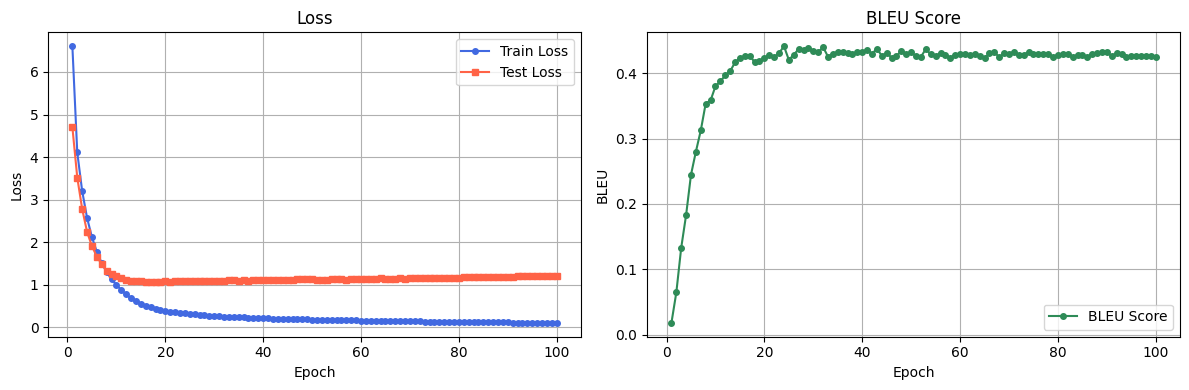

Plot saved to training_metrics.png


In [26]:
plot_metrics(loss_history, bleu_history)